In [1]:
# Import the qiskit library
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit_ibm_runtime import Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator

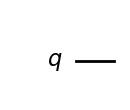

In [2]:
qc = QuantumCircuit(1)
 
# Draw the circuit
qc.draw("mpl")

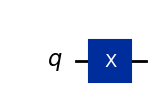

In [3]:
qc = QuantumCircuit(1)  # Prepare the single-qubit quantum circuit
 
# Apply a X gate to qubit 0
qc.x(0)
 
# Draw the circuit
qc.draw("mpl")

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


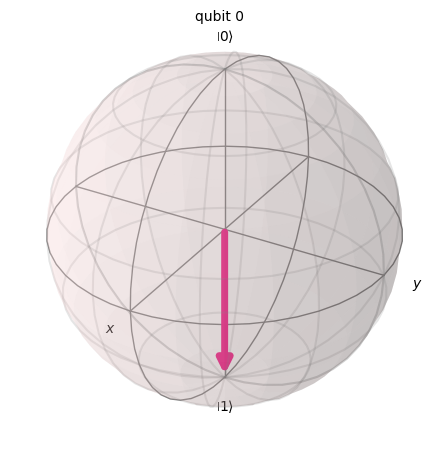

In [4]:
# See the statevector
out_vector = Statevector(qc)
print(out_vector)
 
# Draw a Bloch sphere
plot_bloch_multivector(out_vector)


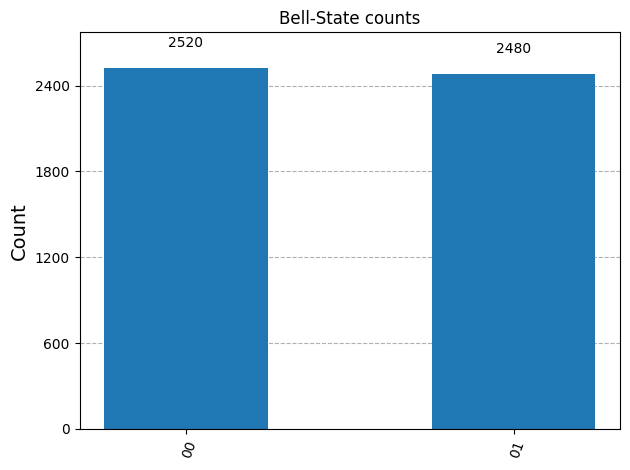

In [5]:
qc = QuantumCircuit(2)
qc.h(0)
qc.measure_all()
simulator = AerSimulator()
qc = transpile(qc, simulator)
result = simulator.run(qc, shots = 5000).result()
counts = result.get_counts(qc)
plot_histogram(counts, title='Bell-State counts')

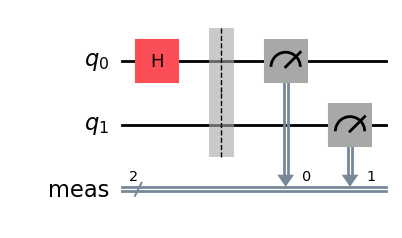

In [6]:
qc.draw("mpl")

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
 

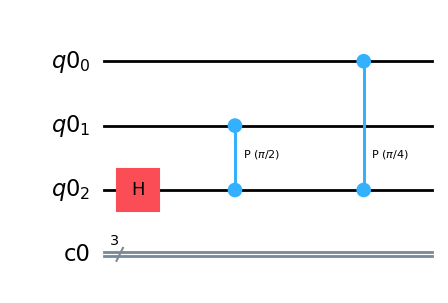

In [8]:
from numpy import pi
# Prepare for 3 qubits circuit
qr = QuantumRegister(3)
cr = ClassicalRegister(3)
qc = QuantumCircuit(qr, cr)

qc.h(2)
qc.cp(pi / 2, 1, 2)  # Controlled-phase gate from qubit 1 to qubit 2
qc.cp(pi / 4, 0, 2)  # Controlled-phase gate from qubit 0 to qubit 2
qc.draw(output="mpl")

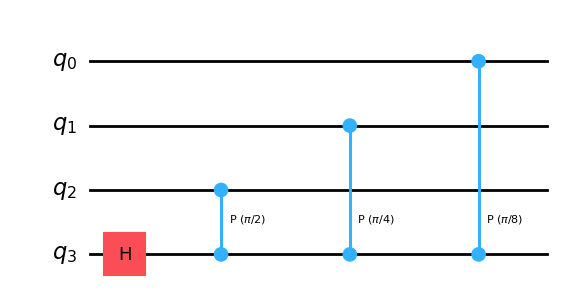

In [9]:
qc = QuantumCircuit(4)
qc.h(3)
qc.cp(pi / 2, 2, 3)  # Controlled-phase gate from qubit 3 to qubit 4
qc.cp(pi / 4, 1, 3)  # Controlled-phase gate from qubit 2 to qubit 4
qc.cp(pi / 8, 0, 3)  # Controlled-phase gate from qubit 1 to qubit 4
qc.draw(output="mpl")

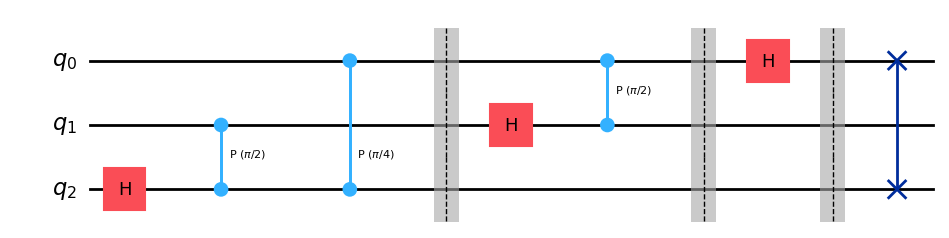

In [10]:
#Crio um cirtcuito de 3 qubits

qft = QuantumCircuit(3)

#Aplico Hadamard ao q_{2}

qft.h(2)

qft.cp(pi / 2, 1, 2) # Rotação controlada do qubit 2 para o qubit 3

qft.cp(pi / 4, 0, 2) # Rotação controlada do qubit 1 para o qubit 3 

#Crio uma barreira

qft.barrier()

#Aplico hadamard ao q_{1}

qft.h(1)

qft.cp(pi/2, 0, 1) # Rotação controlada do qubit 1 para o qubit 2 

#Crio uma barreira

qft.barrier()

#Aplico hadamard ao q_{0}

qft.h(0)

#Crio uma barreira

qft.barrier()
qft.swap(0,2)

qft.draw(output="mpl")

qft.draw("mpl")

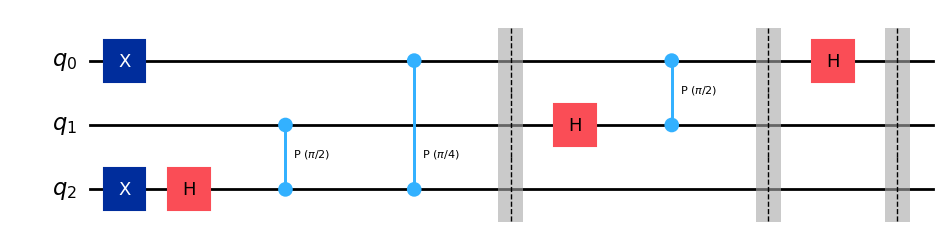

In [11]:
#Crio um cirtcuito de 3 qubits

qft = QuantumCircuit(3)

qft.x(0) #levo o estado do q0 para |1>

qft.x(2) #levo o estado do q2 para |1>

#Aplico Hadamard ao q_{2}

qft.h(2)

qft.cp(pi / 2, 1, 2) # Rotação controlada do qubit 2 para o qubit 3

qft.cp(pi / 4, 0, 2) # Rotação controlada do qubit 1 para o qubit 3 

#Crio uma barreira

qft.barrier()

#Aplico hadamard ao q_{1}

qft.h(1)

qft.cp(pi/2, 0, 1) # Rotação controlada do qubit 1 para o qubit 2 

#Crio uma barreira

qft.barrier()

#Aplico hadamard ao q_{0}

qft.h(0)

#Crio uma barreira

qft.barrier()

qft.draw(output="mpl")

qft.draw("mpl")



#qft.swap(0, 2) # Inverte os qubits 0 e 2

#Statevector = Statevector.from_instruction(qft)

#plot_bloch_multivector(Statevector)

qft.draw("mpl")



C:\Users\samuc\AppData\Local\Temp\ipykernel_10604\2065248445.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(t, inverse=True), range(t))


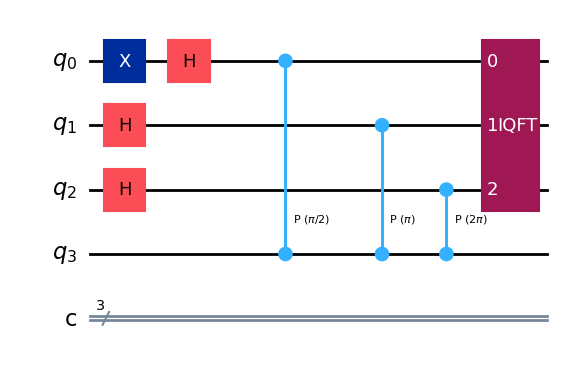

In [12]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from numpy import pi

t = 3  # qubits de precisão

qc = QuantumCircuit(t+1, t)

qc.x(0)

# Hadamards no registrador de contagem
for i in range(t):
    qc.h(i)

# operador U
for i in range(t):
    angle = 2 * pi * (2**i) * 0.25
    qc.cp(angle, i, t)

# QFT inversa
qc.append(QFT(t, inverse=True), range(t))
qc.draw("mpl")
# medir
#qc.measure(range(t), range(t))

#simulator = AerSimulator()
#qc = transpile(qc, simulator)
#result = simulator.run(qc, shots = 5000).result()
#counts = result.get_counts(qc)
#plot_histogram(counts, title='Bell-State counts')

C:\Users\samuc\AppData\Local\Temp\ipykernel_10604\415419094.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(3, inverse=True), [0, 1, 2])


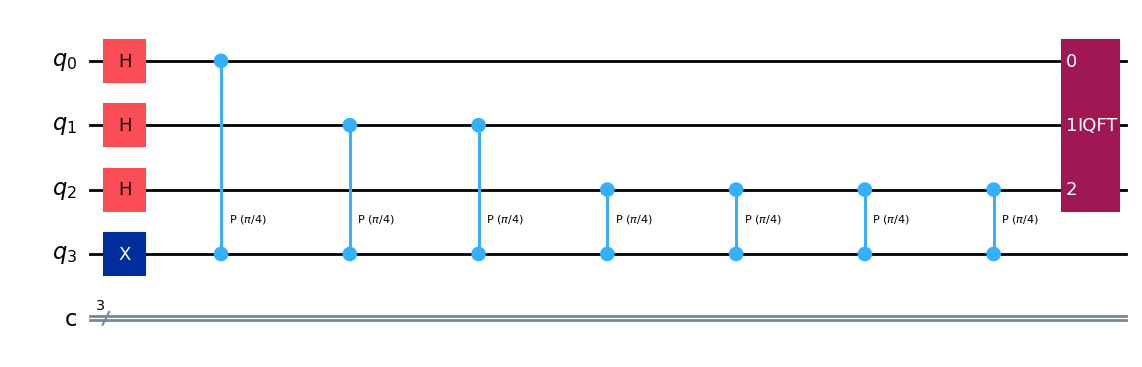

In [13]:
#Importa as devidas bibliotecas
from qiskit.circuit.library import QFT
from math import pi
# Cria um circuito de 4 qubits 
qpe = QuantumCircuit(4, 3)
 
# Aplica uma porta H aos contadores
for qubit in range(3):
    qpe.h(qubit)
 
# Prepara nosso autovetor |1>
qpe.x(3)

# Realiza as rotações controladas equivalentes a pi/4 do operador T
angulo = pi / 4
repete = 1
for contadores in range(3):
    for i in range(repete):
        qpe.cp(angulo, contadores, 3)
    repete *= 2
 
# Aplica a QFT inversa nos qubits q0, q1 e q2
qpe.append(QFT(3, inverse=True), [0, 1, 2])
 
#for n in range(3):
#    qpe.measure(n, n)

qpe.draw("mpl")



C:\Users\samuc\AppData\Local\Temp\ipykernel_10604\579897724.py:25: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(3, inverse=True), [0, 1, 2]) # Aplica a QFT inversa nos qubits q0, q1 e q2


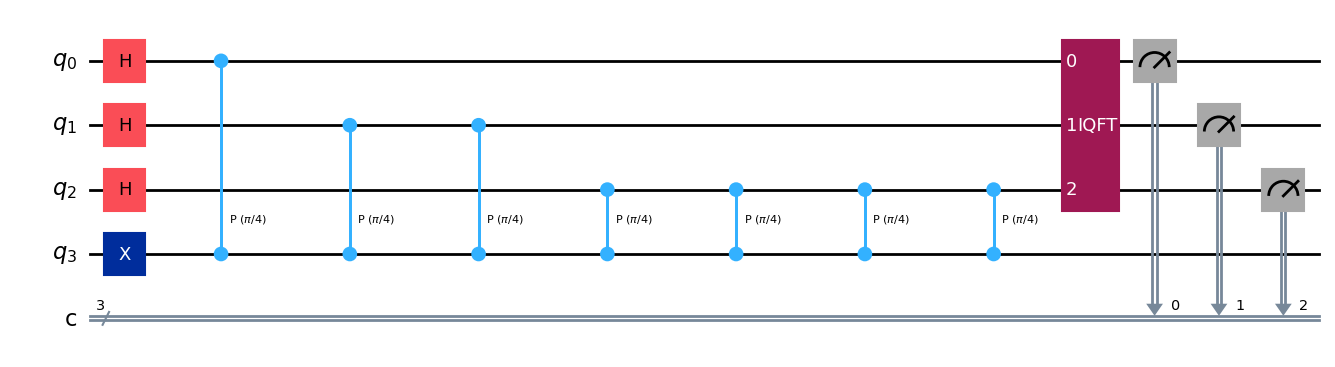

In [14]:
from qiskit.circuit.library import QFT #Importa as devidas bibliotecas

from math import pi

qpe = QuantumCircuit(4, 3)# Cria um circuito de 4 qubits 

for qubit in range(3): # Aplica uma porta H aos contadores

    qpe.h(qubit)

qpe.x(3) # Prepara nosso autovetor |1>

angulo = pi / 4 # Realiza as rotações controladas equivalentes a pi/4 do operador T

repete = 1

for contadores in range(3):

    for i in range(repete):

        qpe.cp(angulo, contadores, 3)

    repete *= 2

qpe.append(QFT(3, inverse=True), [0, 1, 2]) # Aplica a QFT inversa nos qubits q0, q1 e q2

for n in range(3):

    qpe.measure(n, n)

qpe.draw("mpl")

#aer_sim = AerSimulator()

#pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)

#t_qpe = pm.run(qpe)

#sampler = Sampler(mode=aer_sim)

#job = sampler.run([t_qpe], shots=4096)

#resultado = job.result()[0].data.c.get_counts()

#plot_histogram(resultado)



In [15]:
#Matriz Exponenciação Modular
import math

"""def cria_matriz(N, x):
    L = math.ceil(math.log2(N))
    D = 2**L
    matriz = []
    for i in range(D):
        matriz.append([0]*D)

    for j in range(D):
        if j < D:
            temp = (x ** j) % N
            matriz[temp][j] = 1
    return matriz
"""

def imprime_matriz(M):
    for linha in range(len(M)):
        for coluna in range(len(M[linha])):
            print(f"{M[linha][coluna]}\t", end="")
        print()  
        
def cria_matriz(N, a, L):

    dimensao = 2**L
    M = np.zeros((dimensao, dimensao))  #numpy para criar matriz de zeros 2^L x 2^L
    for y in range(dimensao):
        if y < N:
            M[(a * y) % N, y] = 1     #para a colyna y (primeiro registrador) 1 na linha a^yMod(N)
        else:
            M[y,y] = 1      #garante unitariedade para o nosso operador, evitando linhas/colunas vazias
    
    return M

#print(linha)
N = int(input("Digite o N: "))
a = int(input("Digite o a: "))
L = math.ceil(math.log2(N))

M = cria_matriz(N, a, L)
imprime_matriz(M)

NameError: name 'np' is not defined

In [ ]:
"""Algoritmo de Shor / Shor's Algorithm"""

import math
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from math import gcd
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.circuit.library import UnitaryGate

N = int(input("Digite o N: ")) 
L = math.ceil(math.log2(N))         #função que calcula Log2(N) 

'==================  Grupo Multiplicativo (possíveis "a") =================='

vetor_a = []
for i in range(1,N):            
    if gcd(i, N) == 1:
        vetor_a.append(i)         #armazena os possíveis valores de "a" em um vetor do python

'==================  Função cria matriz =================='

def cria_matriz(N, a, L):

    dimensao = 2**L
    M = np.zeros((dimensao, dimensao))  #numpy para criar matriz de zeros 2^L x 2^L
    for y in range(dimensao):
        if y < N:
            M[(a * y) % N, y] = 1     #para a colyna y (primeiro registrador) 1 na linha a^yMod(N)
        else:
            M[y,y] = 1      #garante unitariedade para o nosso operador, evitando linhas/colunas vazias
    
    return M

'==================  Declara matriz como operador =================='

def cria_porta_controlada(M, expoente):            #declara função que cria exponenciação de porta
    Up = np.linalg.matrix_power(M, expoente)       #linalg.matrix_power é uma função docula M^expoente
    op = Operator(Up) #numpy cal
    assert op.is_unitary(), f"U^{expoente} não é unitária!"
    porta = op.to_instruction()              #transforma operador em instrução que qiskit entende
    return porta.control(1)                         #.control(1) é uma função do qiskit que transforma um operador em porta controlada (no caso, por 1 qubit)

i=0
sucesso = False
while i < len(vetor_a):
    a = vetor_a[i]
    M = cria_matriz(N, a, L)
    operador = Operator(M) 
    assert operador.is_unitary(), "U não é unitária!"  # assert para verificar unitariedade de matriz


    '==================  Cria o circuito =================='

    num_alvo = L  # Número de qubits alvo (L)
    num_controle = (2*L)  # Número de qubits de controle (t)

    alvo = QuantumRegister(num_alvo, name="L")
    controle = QuantumRegister(num_controle, name="t")
    saida = ClassicalRegister(num_controle)
    shor = QuantumCircuit(controle, alvo, saida) # Declara sistema (t, L e bits clássicos)

    for k in range(num_controle):
        shor.h(controle[k])         #coloca registradores "t" em superpsição
    shor.x(alvo[0])                 #coloca registrador "L" em estado |1>

    '==================  Aplica as operações =================='

    for j in range(num_controle):
        expoente = 2 ** j
        operacao_controlada = cria_porta_controlada(M, expoente)        #aplica porta conforme registrador |j>
        shor.append(operacao_controlada, [controle[j]] + list(alvo))    #aplica o operador controlado e pede para mapear sua ação (operação, [qubit controle] + alvo)

    '==================  Aplica QFT inversa =================='

    shor.append(QFTGate(num_controle).inverse(), range(num_controle))      #porta do qiskit que aplica a qft QFTGate((qubits a serem aplicados), (bits clássicos))

    '==================  Desenha circuito =================='
    shor.measure(range(num_controle),range(num_controle))

    '==================  Simulador =================='
    
    sim = AerSimulator()
    trans = transpile(shor, sim)
    result = sim.run(trans, shots=1024).result()
    counts = result.get_counts(shor)

    '==================  Maior pico =================='
    condicao_mudar_a = False
    while True:
        while True:                                    #Laço garante que não escolheremos |0...00>
            if not counts:                        #verifica se nenhum dos picos do nosso a gera um valor válido para r
                condicao_mudar_a = True
                break
            candidato_maior_pico = max(counts, key = counts.get)        #extrai o pico mais frequente 
            l = int(candidato_maior_pico, 2)                        #transforma valor binário do pico mais frequente em base decimal
            if l > 0:
                break
            del counts[candidato_maior_pico]            #se não entrar no if, candidato_maior_pico = 0...000 e, assim, é deletado, laço escolhe próximo pico

        if condicao_mudar_a:                #se condição for verdadeira, já verificamos todos os picos e o "a" atual não é válido
            break
        '==================  Frações contínuas para extrair r =================='

        fracao = l / 2**num_controle    #equivalente à fração l/2^t
        frac = Fraction(fracao)         #função do python que calcula a menor simplificação
        r = frac.denominator
    
        '==================  Extraindo fatores primos =================='

        if r % 2 != 0:
            del counts[candidato_maior_pico]
            continue
        exp_mod = int(a**(r//2) % N)
        
        if exp_mod == N - 1:
            condicao_mudar_a = True         #achados fatores triviais, break quebra o laço atual para mudar de a
            break
        elif exp_mod == 1:
            del counts[candidato_maior_pico]
            continue
        
        fator_1 = gcd(exp_mod -1, N)
        fator_2 = gcd(exp_mod +1, N)
        if fator_1 * fator_2 != N:
            del counts[candidato_maior_pico]
            continue
        else:
            sucesso = True
            break

    if sucesso:
        print(f"a = {a}")
        print(f"r = {r}")       
        print(f"gcd({a}^{r}/2 -1, {N}) = {fator_1}")
        print(f"gcd({a}^{r}/2 +1, {N})= {fator_2}")
        print(f"para N = {N} e a = {a}, nossos fatores primos são {fator_1} e {fator_2}")
        break
    
    i += 1

'==================  Decriptando Mensagem =================='

#phi = (fator_1 - 1) * (fator_2 -1)      
#chave_publica_e = int(input("Digite o e: "))   
#d = pow(e, -1, phi)                      
#C = int(input("Digite a mensagem criptografada: "))     
#M = pow(C, d, N)          

#print(M)

a = 12
r = 4
gcd(12^4/2 -1, 55) = 11
gcd(12^4/2 +1, 55)= 5
para N = 55 e a = 12, nossos fatores primos são 11 e 5


'==================  Decriptando Mensagem =================='

In [31]:
"""Do Samuquera 1 - Otimizado"""

import math
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from math import gcd
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Operator
from qiskit_aer import Aer
import numpy as np
from qiskit.circuit.library import UnitaryGate

N = int(input("Digite o N: ")) 
L = math.ceil(math.log2(N))         # função que calcula Log2(N) 

'==================  Grupo Multiplicativo (possíveis "a") =================='

vetor_a = []
for i in range(1, N):            
    if gcd(i, N) == 1:
        vetor_a.append(i)         # armazena os possíveis valores de "a" em um vetor

'==================  Função cria matriz =================='

def cria_matriz(N, a_atual, L):
    dimensao = 2**L
    M = np.zeros((dimensao, dimensao))  # numpy para criar matriz de zeros 2^L x 2^L
    for y in range(dimensao):
        if y < N:
            M[(a_atual * y) % N, y] = 1    # mapeamento modular direto
        else:
            M[y, y] = 1      # garante unitariedade para o operador (padding)
    return M

'==================  Loop Principal de Tentativas de "a" =================='

i = 0
sucesso = False
while i < len(vetor_a):
    a = vetor_a[i]

    '==================  Cria o circuito =================='
    num_alvo = L  # Número de qubits alvo (L)
    num_controle = (2*L)  # Número de qubits de controle (t)

    alvo = QuantumRegister(num_alvo, name="L")
    controle = QuantumRegister(num_controle, name="t")
    saida = ClassicalRegister(num_controle)
    shor = QuantumCircuit(controle, alvo, saida)

    for k in range(num_controle):
        shor.h(controle[k])
    shor.x(alvo[0])
    shor.barrier()

    '==================  Aplica as operações controladas otimizadas =================='
    # Evita matrix_power calculando diretamente o equivalente modular para a_potencia
    for j in range(num_controle):
        a_potencia = pow(a, 2**j, N)
        M_j = cria_matriz(N, a_potencia, L)
        
        op = Operator(M_j)
        assert op.is_unitary(), f"U^{2**j} não é unitária!"
        porta = op.to_instruction().control(1)
        shor.append(porta, [controle[j]] + list(alvo))

    '==================  Aplica QFT inversa =================='
    shor.barrier()
    shor.append(QFTGate(num_controle).inverse(), range(num_controle))
    shor.measure(range(num_controle), range(num_controle))

    '==================  Simulador Otimizado =================='
    # Usando o statevector_simulator do Aer para maior performance em circuitos unitários
    sim = Aer.get_backend('statevector_simulator')
    trans = transpile(shor, sim)
    
    # Reduzido levemente os shots para ganhar velocidade, mantendo alta precisão
    result = sim.run(trans, shots=512).result()
    counts = result.get_counts(shor)

    '==================  Maior pico =================='
    condicao_mudar_a = False
    while True:
        while True:                                    # Laço garante que não escolheremos |0...00>
            if not counts:                        # verifica se nenhum dos picos gera valor válido
                condicao_mudar_a = True
                break
            candidato_maior_pico = max(counts, key = counts.get)        # extrai o pico mais frequente 
            l = int(candidato_maior_pico, 2)                        # transforma valor binário em decimal
            if l > 0:
                break
            del counts[candidato_maior_pico]            # deleta pico zero e escolhe o próximo

        if condicao_mudar_a:                # se esgotou os picos, muda o "a"
            break
            
        '==================  Frações contínuas para extrair r =================='
        fracao = l / 2**num_controle    # equivalente à fração l/2^t
        frac = Fraction(fracao)         # menor simplificação
        r = frac.denominator
    
        '==================  Extraindo fatores primos =================='
        if r % 2 != 0:
            del counts[candidato_maior_pico]
            continue
            
        exp_mod = int(a**(r//2) % N)
        
        if exp_mod == N - 1:
            condicao_mudar_a = True        # fatores triviais, muda de "a"
            break
        elif exp_mod == 1:
            del counts[candidato_maior_pico]
            continue
        
        fator_1 = gcd(exp_mod - 1, N)
        fator_2 = gcd(exp_mod + 1, N)
        
        if fator_1 * fator_2 != N:
            del counts[candidato_maior_pico]
            continue
        else:
            sucesso = True
            break

    if sucesso:
        print(f"a = {a}")
        print(f"r = {r}")      
        print(f"gcd({a}^{r}/2 - 1, {N}) = {fator_1}")
        print(f"gcd({a}^{r}/2 + 1, {N}) = {fator_2}")
        print(f"Para N = {N} e a = {a}, nossos fatores primos são {fator_1} e {fator_2}")
        break
    
    i += 1

KeyboardInterrupt: 